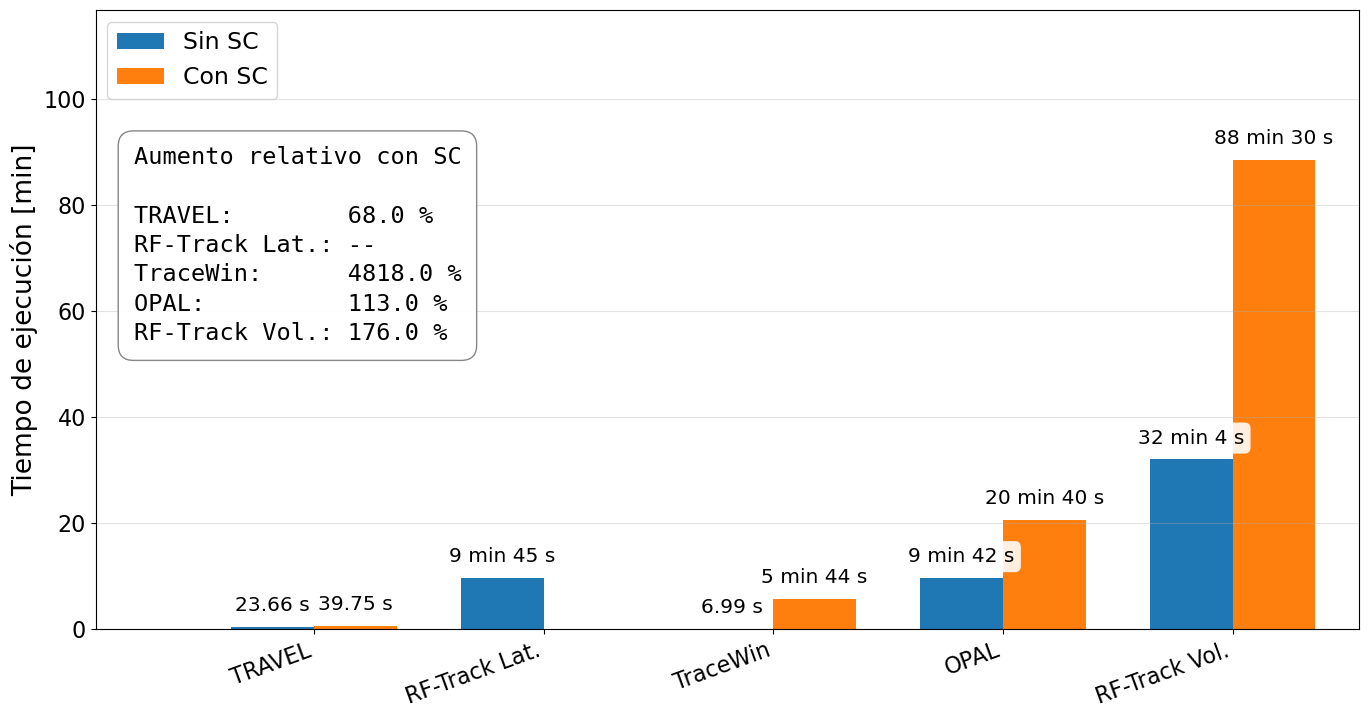

In [5]:
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

# =========================
# Configuración global de fuente
# =========================

plt.rcParams.update({
    "font.size": 17,
    "axes.labelsize": 19,
    "xtick.labelsize": 16,
    "ytick.labelsize": 16,
    "legend.fontsize": 17,
})

# =========================
# Datos de tiempos
# =========================

codigos = [
    "TRAVEL",
    "RF-Track Lat.",
    "TraceWin",
    "OPAL",
    "RF-Track Vol."
]

# Tiempos en segundos
tiempo_sin_sc = np.array([
    23.663,
    9*60 + 45,
    6.99,
    582.32,
    32*60 + 4
], dtype=float)

tiempo_con_sc = np.array([
    39.75,
    np.nan,
    343.77,
    1240.4,
    88*60 + 30
], dtype=float)

# En minutos para el eje Y
tiempo_sin_sc_min = tiempo_sin_sc / 60
tiempo_con_sc_min = tiempo_con_sc / 60


# =========================
# Formato de etiquetas
# =========================

def format_time(seconds):
    if np.isnan(seconds):
        return ""

    if seconds < 60:
        return f"{seconds:.2f} s"

    minutes = int(seconds // 60)
    sec = seconds % 60

    if sec < 1:
        return f"{minutes} min"

    return f"{minutes} min {sec:.0f} s"


# =========================
# Aumento relativo
# =========================

aumento_relativo = (tiempo_con_sc - tiempo_sin_sc) / tiempo_sin_sc * 100

def format_increase(value):
    if np.isnan(value):
        return "--"
    return f"{value:.1f} %"


# =========================
# Plot
# =========================

x = np.arange(len(codigos))
width = 0.36

fig, ax = plt.subplots(figsize=(14, 7.5))

bars1 = ax.bar(
    x - width/2,
    tiempo_sin_sc_min,
    width,
    label="Sin SC"
)

bars2 = ax.bar(
    x + width/2,
    tiempo_con_sc_min,
    width,
    label="Con SC"
)

ax.set_ylabel("Tiempo de ejecución [min]")
ax.set_xticks(x)
ax.set_xticklabels(codigos, rotation=20, ha="right")
ax.tick_params(axis="both", labelsize=16)
ax.grid(True, axis="y", alpha=0.35)
ax.legend(loc="upper left")

# Más margen a la izquierda para la caja
ax.set_xlim(-0.95, len(codigos) - 0.45)

max_time = np.nanmax([np.nanmax(tiempo_sin_sc_min), np.nanmax(tiempo_con_sc_min)])
ax.set_ylim(0, max_time * 1.32)


# =========================
# Etiquetas encima de barras
# =========================

def add_labels(bars, times_seconds):
    for bar, seconds in zip(bars, times_seconds):
        if np.isnan(seconds):
            continue

        height = bar.get_height()
        y_text = height + max_time * 0.025

        ax.text(
            bar.get_x() + bar.get_width()/2,
            y_text,
            format_time(seconds),
            ha="center",
            va="bottom",
            fontsize=14.5,
            clip_on=False,
            bbox=dict(
                boxstyle="round,pad=0.30",
                facecolor="white",
                edgecolor="none",
                alpha=0.88
            )
        )

add_labels(bars1, tiempo_sin_sc)
add_labels(bars2, tiempo_con_sc)


# =========================
# Caja de texto con aumentos relativos
# =========================

texto_aumentos = (
    "Aumento relativo con SC\n\n"
    f"TRAVEL:        {format_increase(aumento_relativo[0])}\n"
    f"RF-Track Lat.: {format_increase(aumento_relativo[1])}\n"
    f"TraceWin:      {format_increase(aumento_relativo[2])}\n"
    f"OPAL:          {format_increase(aumento_relativo[3])}\n"
    f"RF-Track Vol.: {format_increase(aumento_relativo[4])}"
)

ax.text(
    0.03, 0.78,
    texto_aumentos,
    transform=ax.transAxes,
    ha="left",
    va="top",
    fontsize=17,
    family="monospace",
    linespacing=1.35,
    bbox=dict(
        boxstyle="round,pad=0.65",
        facecolor="white",
        edgecolor="gray",
        alpha=0.95
    )
)

plt.tight_layout()

Path("tiempos").mkdir(exist_ok=True)
plt.savefig("tiempos_ejecucion_space_charge.pdf", bbox_inches="tight")
plt.show()